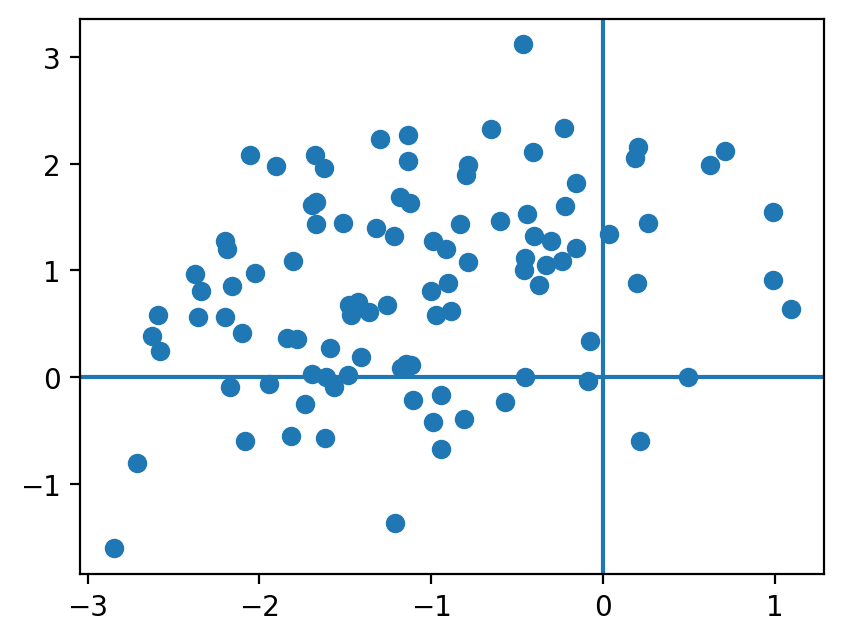

In [21]:
import numpy as np 
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt 

M   = np.array([-1,1]) 
COV = np.array([[ 1, 0.3 ], [0.3 , 1]])
L   = np.linalg.cholesky(COV)

z   = np.random.normal( 0,1 ,size = (100,2) )
d   = M + z@L

fig,ax = plt.subplots()
ax.scatter(d[:,0], d[:,1])

ax.axhline(0)
ax.axvline(0)


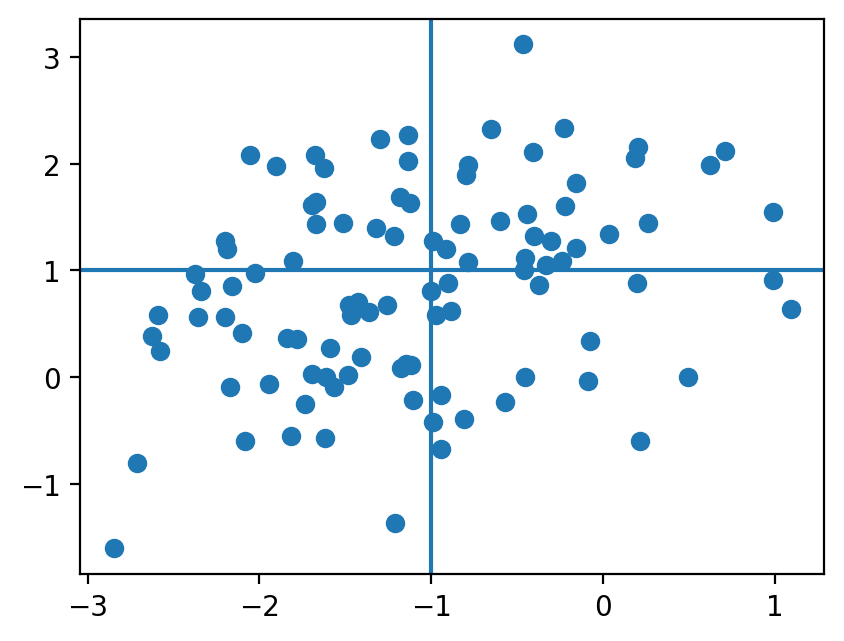

In [22]:
fig,ax = plt.subplots()
ax.scatter(d[:,0], d[:,1])

ax.axhline(1)
ax.axvline(-1)




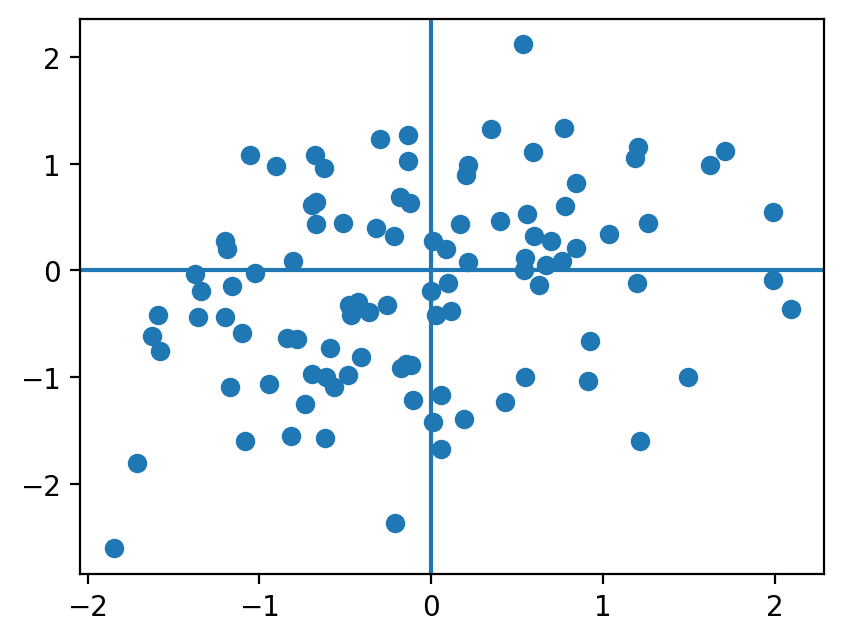

In [23]:
fig,ax = plt.subplots()

d_centered = d - M

ax.scatter(d_centered[:,0], d_centered[:,1])
ax.axhline(0)
ax.axvline(0)



0.7901475351328051
0.7965919311255053


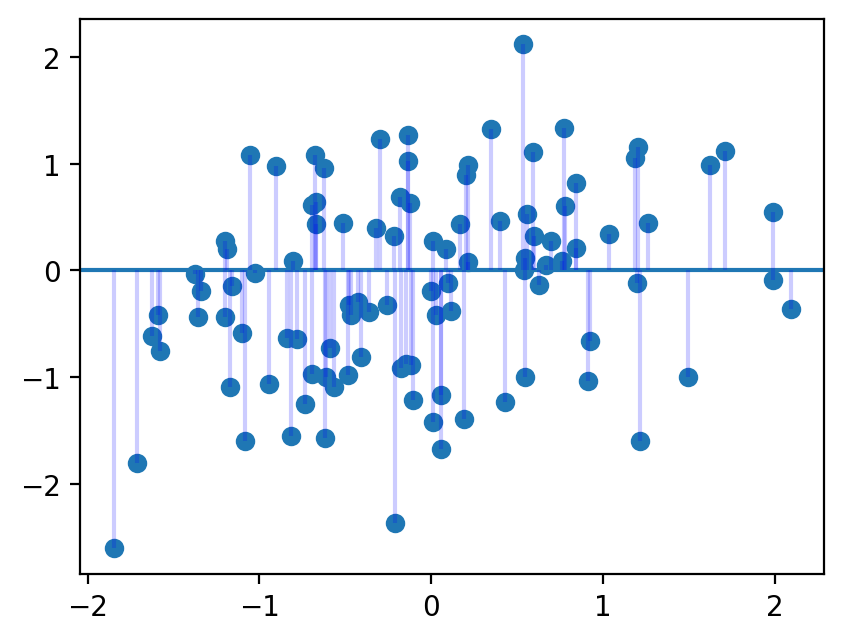

In [24]:
N = len(d_centered)

Var_hline1 = np.var( d_centered[:,0]  )
Var_hline2 = (1/N)*d_centered[:,0].T@d_centered[:,0].T

print(Var_hline1)
print(Var_hline2)

fig,ax = plt.subplots()
ax.scatter(d_centered[:,0], d_centered[:,1])
ax.axhline(0)
ax.vlines(x=d_centered[:,0], ymin=0, ymax=d_centered[:,1], colors='blue',alpha=0.2)


In [25]:

l,u         = np.linalg.eigh(COV)
l_est,u_est = np.linalg.eigh( d_centered.T @ d_centered/N )



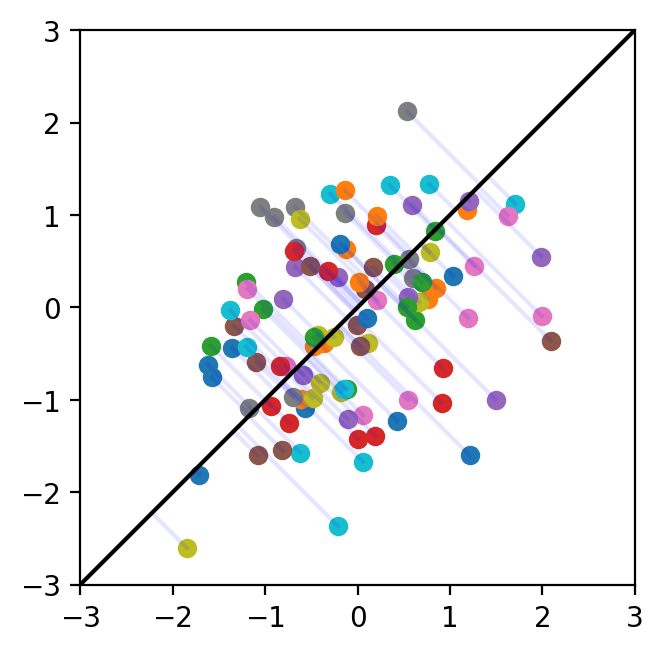

In [26]:

u      = np.array([1,1]).reshape(2,1)
u      = u/np.linalg.norm(u)

alphas = (d_centered @ u) #<-- N X 1

fig, ax = plt.subplots()

for point,alpha in zip(d_centered, alphas):
    alpha = float(alpha)
    u0    = float(u[0])
    u1    = float(u[1])
    ax.plot( [alpha*u0, point[0] ] ,  [alpha*u1, point[1]  ], color="blue", alpha=0.1  )
    ax.scatter( point[0], point[1] )
    
ax.plot( [-3,3], [-3,3], color="black" )  

ax.set_aspect("equal")
ax.set_xlim(-3,3)
ax.set_ylim(-3,3)
plt.show()

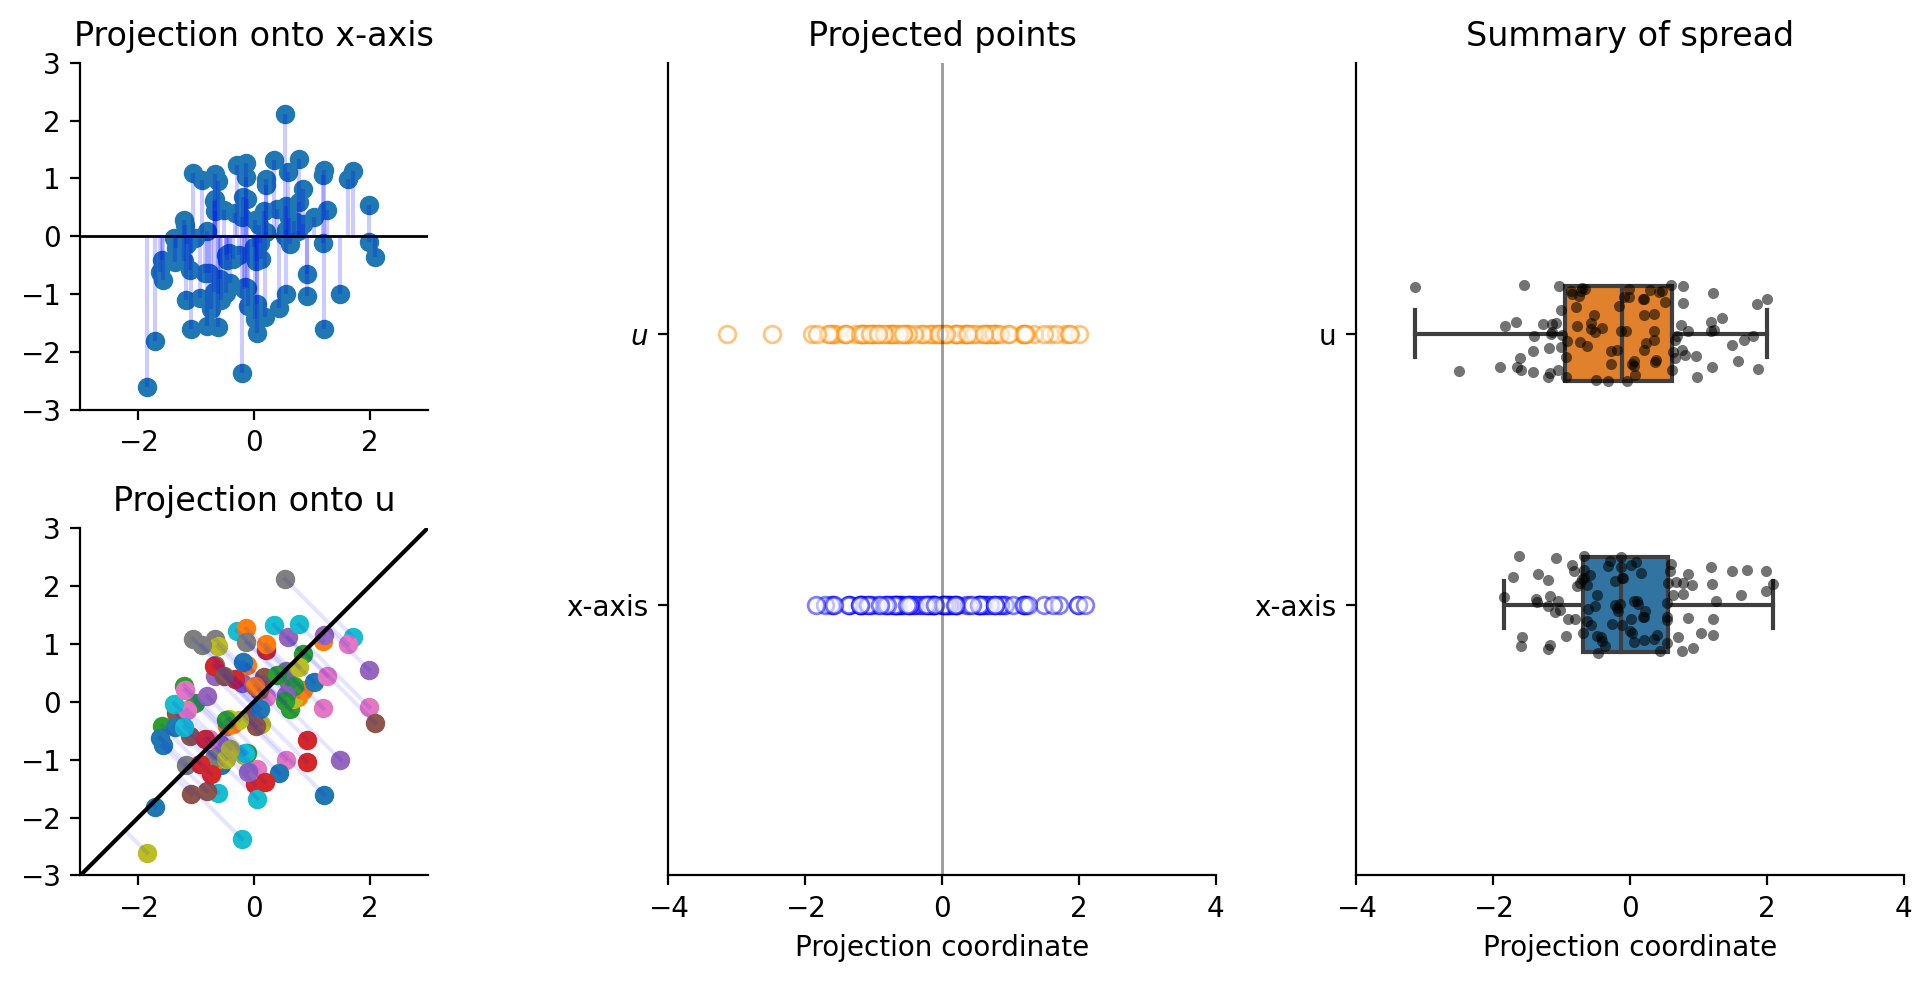

In [60]:
fig = plt.figure(figsize=(10, 5))
gs  = fig.add_gridspec(2, 3)

ax00 = fig.add_subplot(gs[0, 0])
ax10 = fig.add_subplot(gs[1, 0])

ax_proj = fig.add_subplot(gs[:, 1])  # joined second column
ax_box  = fig.add_subplot(gs[:, 2])  # joined third column

# ------------------------------------------------------------
# First row, first column: original data + projection to x-axis
# ------------------------------------------------------------
ax = ax00
ax.scatter(d_centered[:, 0], d_centered[:, 1])
ax.axhline(0, color="black", linewidth=1)
ax.vlines(x=d_centered[:, 0], ymin=0, ymax=d_centered[:, 1],colors="blue",alpha=0.2)
ax.set_xlim(-3, 3)
ax.set_ylim(-3, 3)
ax.set_aspect("equal")
ax.set_title("Projection onto x-axis")

# ------------------------------------------------------------
# Second row, first column: original data + projection to u
# ------------------------------------------------------------
u = np.array([1, 1], dtype=float).reshape(2, 1)
u = u / np.linalg.norm(u)

alphas = d_centered @ u          # N x 1
projs  = alphas @ u.T            # N x 2

ax = ax10
for point, proj in zip(d_centered, projs):
    ax.plot([proj[0], point[0]],[proj[1], point[1]],color="blue",alpha=0.1,)
    ax.scatter(point[0], point[1])

ax.plot([-3, 3], [-3, 3], color="black")
ax.set_xlim(-3, 3)
ax.set_ylim(-3, 3)
ax.set_aspect("equal")
ax.set_title(r"Projection onto u")

# ------------------------------------------------------------
# Joined second column: compare 1D projected coordinates
# ------------------------------------------------------------
x_proj = d_centered[:, 0]
u_proj = alphas.reshape(-1)

ax = ax_proj

ax.scatter(x_proj
           ,np.zeros_like(x_proj)
           ,facecolor="white",edgecolor="blue",alpha=0.5,label="x-axis")

ax.scatter(u_proj ,np.ones_like(u_proj) ,facecolor="white",edgecolor="darkorange",alpha=0.5,label="u")

ax.set_xlim(-4, 4)
ax.set_ylim(-1, 2)
ax.set_yticks([0, 1])
ax.set_yticklabels(["x-axis", r"$u$"])
ax.axvline(0, color="black", linewidth=1, alpha=0.4)
ax.set_xlabel("Projection coordinate")
ax.set_title("Projected points")

# ------------------------------------------------------------
projected_data = pd.DataFrame({
    "p": np.concatenate([x_proj, u_proj]),
    "projection": ( ["x-axis"] * len(x_proj) + ["u"] * len(u_proj) )})

ax = ax_box

sns.boxplot(x="p"
    ,y="projection"
    ,data=projected_data
    ,ax=ax
    ,width=0.35
    ,showcaps=True
    ,showfliers=False
    #,boxprops={"facecolor": "none", "edgecolor": "black", "linewidth": 1.5}
    #,whiskerprops={"color": "black", "linewidth": 1.2}
    #,capprops={"color": "black", "linewidth": 1.2}
    #,medianprops={"color": "black", "linewidth": 2}
)

sns.stripplot(x="p",y="projection",data=projected_data,ax=ax,jitter=0.18,size=4,alpha=0.55,color="black")

ax.set_xlim(-4, 4)
ax.set_ylim(-1,2)
ax.set_xlabel("Projection coordinate")
ax.set_ylabel("")
ax.set_title("Summary of spread")

sns.despine(fig=fig)

plt.tight_layout()
plt.show()

In [41]:
np.var( d_centered[:,0] ) 

0.7901475351328051

In [42]:
np.var(alphas)

1.0594926841311887